In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix


In [124]:
# Load the dataset
df=pd.read_csv('/workspaces/Telecom-Churn-Prediction/data/teleco_churn.csv')
# Display the first few rows of the dataset
print(df.head())


   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [125]:
#check for missing values
print(df.isnull().sum()) # no missing values in the dataset


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [126]:
df.dtypes 

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [127]:
# type of TotalCharges is object, we need to convert it to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
# Drop rows with NaN in TotalCharges
df.dropna(subset=['TotalCharges'], inplace=True)
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object

In [128]:
# remove customerID column as it is not useful for prediction
df.drop('customerID', axis=1, inplace=True)

In [129]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [130]:
# encoding categorical variables
df['SeniorCitizen'] = df['SeniorCitizen'].astype('category')  # Ensure SeniorCitizen is treated as categorical
df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded.head()

,tenure,MonthlyCharges,TotalCharges,gender_Male,SeniorCitizen_1,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,1,29.85,29.85,False,False,True,False,False,True,False,...,False,False,False,False,False,True,False,True,False,False
1,34,56.95,1889.50,True,False,False,False,True,False,False,...,False,False,False,True,False,False,False,False,True,False
2,2,53.85,108.15,True,False,False,False,True,False,False,...,False,False,False,False,False,True,False,False,True,True
3,45,42.30,1840.75,True,False,False,False,False,True,False,...,False,False,False,True,False,False,False,False,False,False
4,2,70.70,151.65,False,False,False,False,True,False,False,...,False,False,False,False,False,True,False,True,False,True


In [131]:
# remove lines with Nan values in TotalCharges
df_encoded.dropna(subset=['TotalCharges'], inplace=True)


In [132]:
# Data distribution 
print(f"Number of churned customers: {df[df['Churn'] == 'Yes'].shape[0]}")
print(f"Number of non-churned customers: {df[df['Churn'] == 'No'].shape[0]}")

Number of churned customers: 1869
Number of non-churned customers: 5163


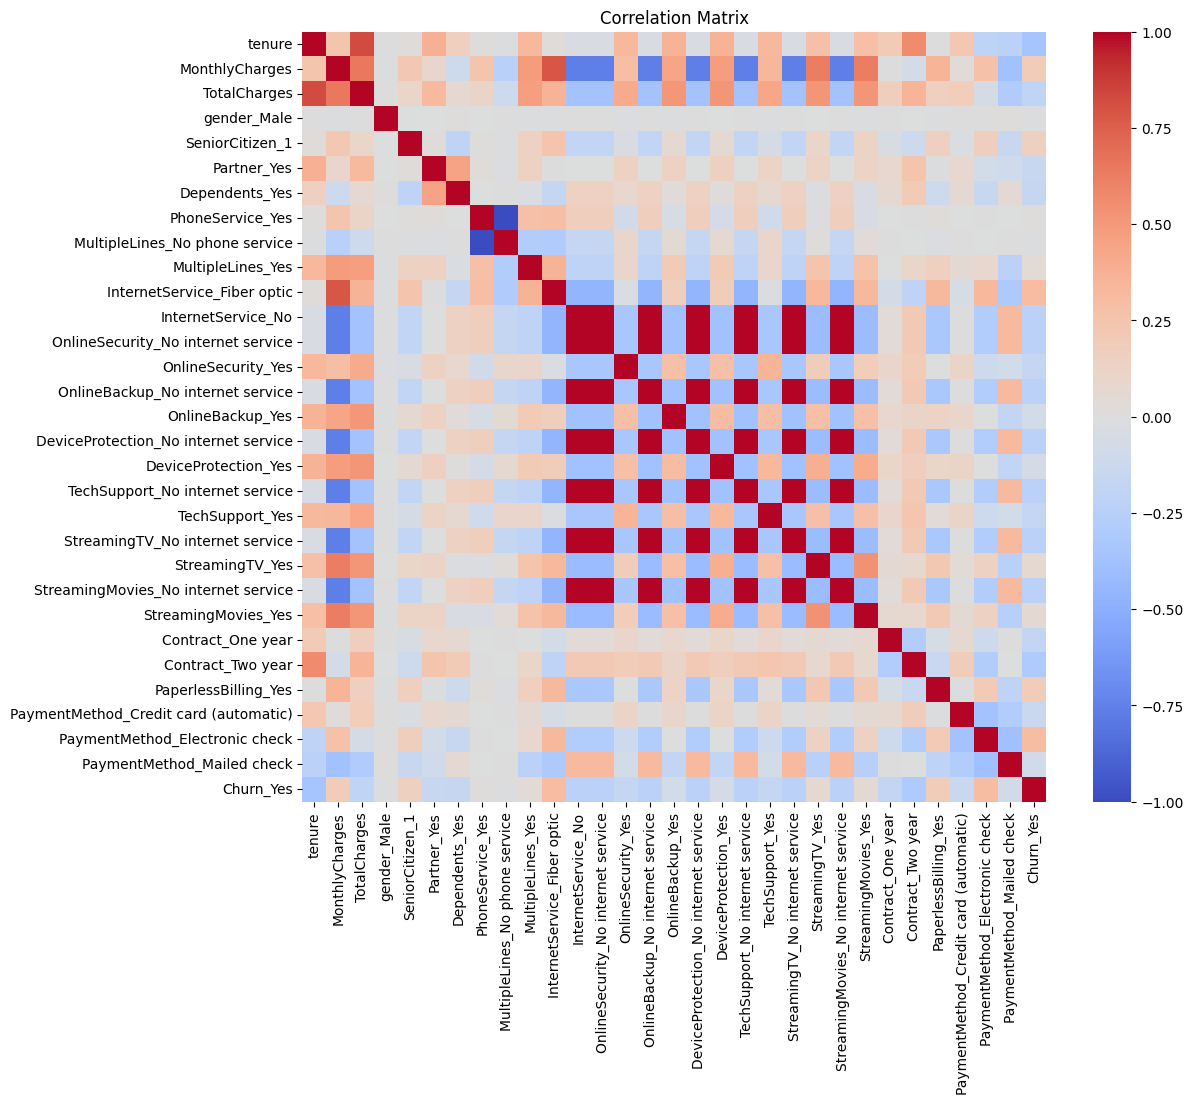

In [133]:
# correlation matrix
plt.figure(figsize=(12,10))
sns.heatmap(df_encoded.corr(), annot=False, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

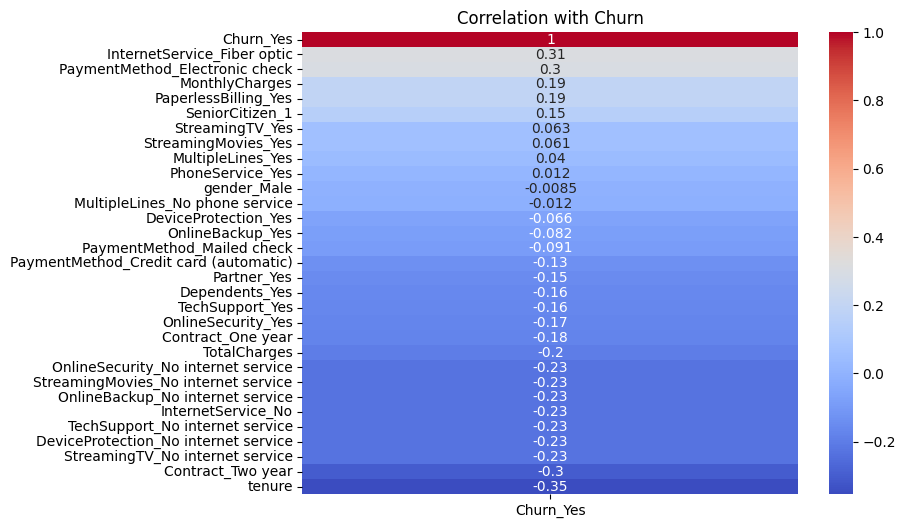

In [134]:
# correlation matrix for numeric features and churn_Yes
plt.figure(figsize=(8,6))
sns.heatmap(df_encoded.corr()[['Churn_Yes']].sort_values(by='Churn_Yes', ascending=False), annot=True, cmap='coolwarm')
plt.title('Correlation with Churn')
plt.show()




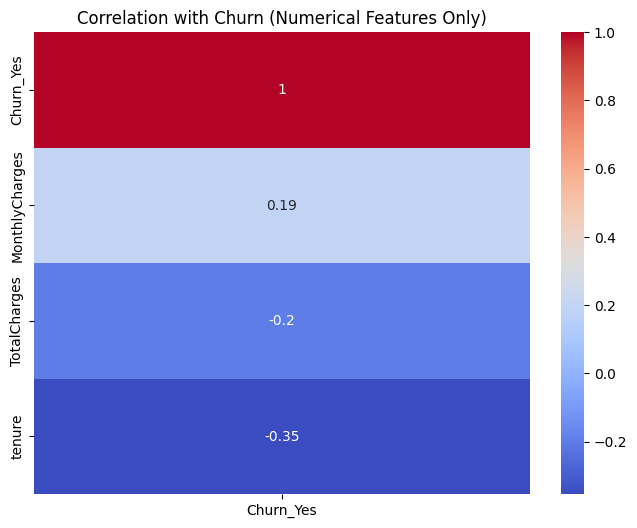

In [135]:
# Correlation heatmap for numerical features only with Churn_Yes
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_Yes']
plt.figure(figsize=(8,6))
sns.heatmap(df_encoded[numerical_cols].corr()[['Churn_Yes']].sort_values(by='Churn_Yes', ascending=False), annot=True, cmap='coolwarm')
plt.title('Correlation with Churn (Numerical Features Only)')
plt.show()

In [136]:
numeric_features=['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_features = [col for col in df.columns if col not in numeric_features + ['Churn']]

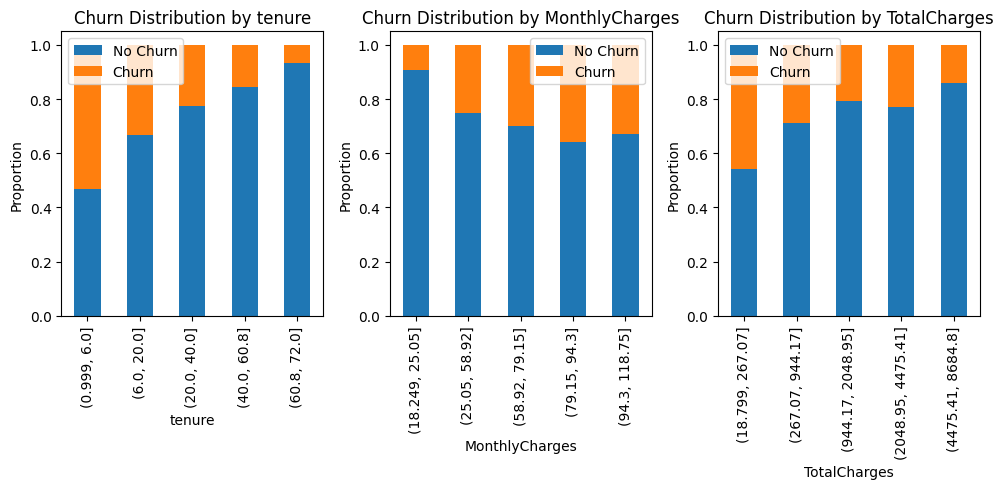

In [137]:
# churn probability by numerical features
ncols = 3
nrows = (len(numerical_features) + ncols - 1) // ncols  # Ceiling division

fig, axes = plt.subplots(nrows, ncols, figsize=(10, 5 * nrows))
axes = axes.flatten()

for i, feature in enumerate(numerical_features):
    df["binned"] = pd.qcut(df[feature], q=5, duplicates="drop")

    churn_rate = pd.crosstab(
        df["binned"],
        df["Churn"],
        
        normalize="index"
    )

    churn_rate.plot(
        kind="bar",
        stacked=True,
        ax=axes[i]
    )
    
    axes[i].set_title(f"Churn Distribution by {feature}")
    axes[i].set_ylabel("Proportion")
    axes[i].set_xlabel(feature)
    axes[i].legend(["No Churn", "Churn"])
    df.drop("binned", axis=1, inplace=True)
plt.tight_layout()
plt.show()



In [138]:
# Feature importance using mutual information
from sklearn.feature_selection import mutual_info_classif

# Prepare data
y = df_encoded['Churn_Yes']
X = df_encoded.drop('Churn_Yes', axis=1)

# Compute mutual information scores
mi_scores = mutual_info_classif(X, y, random_state=42)

# Create a series for easy viewing
mi_series = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)

print("Top features signaling churn (by mutual information):")
print(mi_series)

Top features signaling churn (by mutual information):
tenure                                   0.074005
Contract_Two year                        0.062579
InternetService_Fiber optic              0.052035
MonthlyCharges                           0.048207
PaymentMethod_Electronic check           0.043016
TotalCharges                             0.042425
StreamingTV_No internet service          0.036332
TechSupport_No internet service          0.035248
OnlineSecurity_No internet service       0.034464
OnlineBackup_No internet service         0.030587
StreamingMovies_No internet service      0.026844
PaperlessBilling_Yes                     0.026774
InternetService_No                       0.026717
DeviceProtection_No internet service     0.025149
Dependents_Yes                           0.022617
OnlineSecurity_Yes                       0.020958
TechSupport_Yes                          0.020289
SeniorCitizen_1                          0.014414
PaymentMethod_Credit card (automatic)    0.013

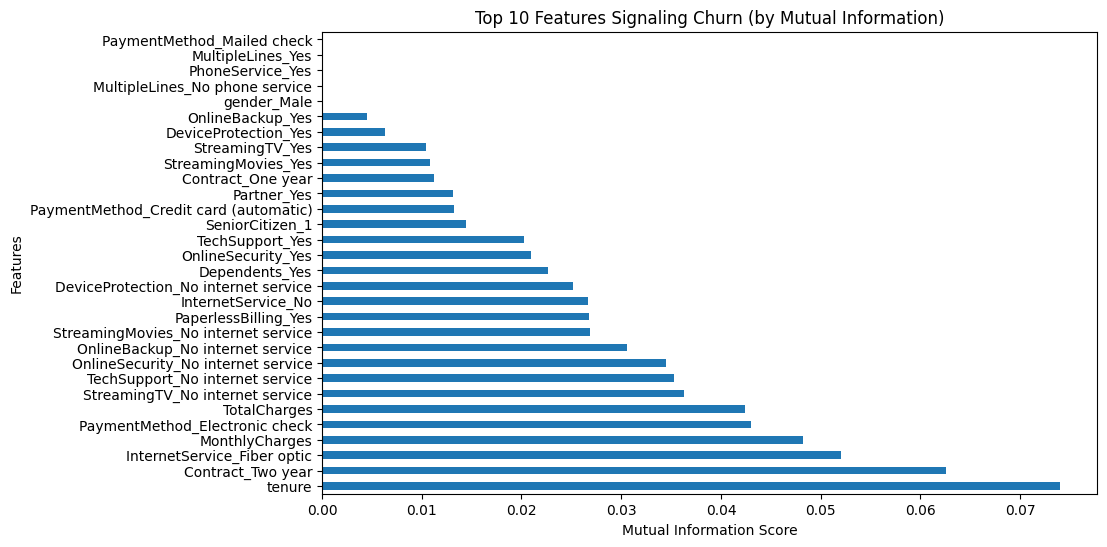

In [139]:
# Visualize top 10 features by mutual information
mi_series.plot(kind='barh', figsize=(10,6))
plt.title('Top 10 Features Signaling Churn (by Mutual Information)')
plt.xlabel('Mutual Information Score')
plt.ylabel('Features')
plt.show()

In [140]:
# Effect size for categorical features using Cramer's V
import numpy as np

cramer_results = {}
n = len(df)  # total sample size
for feature in categorical_features:
    contingency_table = pd.crosstab(df[feature], df['Churn'])
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    # Cramer's V
    k = contingency_table.shape[1]  # number of columns (Churn categories)
    r = contingency_table.shape[0]  # number of rows (feature categories)
    cramer_v = np.sqrt(chi2 / (n * min(k-1, r-1)))
    cramer_results[feature] = cramer_v

# Sort by Cramer's V descending
sorted_cramer = sorted(cramer_results.items(), key=lambda x: x[1], reverse=True)
print("Categorical features ranked by Cramer's V (effect size):")
for feature, v in sorted_cramer:
    print(f"{feature}: Cramer's V={v:.4f}")

Categorical features ranked by Cramer's V (effect size):
Contract: Cramer's V=0.4096
OnlineSecurity: Cramer's V=0.3470
TechSupport: Cramer's V=0.3425
InternetService: Cramer's V=0.3219
PaymentMethod: Cramer's V=0.3030
OnlineBackup: Cramer's V=0.2919
DeviceProtection: Cramer's V=0.2812
StreamingMovies: Cramer's V=0.2307
StreamingTV: Cramer's V=0.2301
PaperlessBilling: Cramer's V=0.1911
Dependents: Cramer's V=0.1628
SeniorCitizen: Cramer's V=0.1501
Partner: Cramer's V=0.1497
MultipleLines: Cramer's V=0.0400
PhoneService: Cramer's V=0.0111
gender: Cramer's V=0.0082


In [141]:
# Chi-Square test of independence for categorical features
from scipy.stats import chi2_contingency
# p-value threshold for significance
p_value_threshold = 0.05

# print significant features based on chi-square test
print("Significant features based on Chi-Square test of independence:")
for feature in categorical_features:
    contingency_table = pd.crosstab(df[feature], df['Churn'])
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    
    if p < p_value_threshold:
        print(f"{feature}: p-value = {p:.4f} (Significant)")
    else:
        print(f"{feature}: p-value = {p:.4f} (Not Significant)")

Significant features based on Chi-Square test of independence:
gender: p-value = 0.4905 (Not Significant)
SeniorCitizen: p-value = 0.0000 (Significant)
Partner: p-value = 0.0000 (Significant)
Dependents: p-value = 0.0000 (Significant)
PhoneService: p-value = 0.3499 (Not Significant)
MultipleLines: p-value = 0.0036 (Significant)
InternetService: p-value = 0.0000 (Significant)
OnlineSecurity: p-value = 0.0000 (Significant)
OnlineBackup: p-value = 0.0000 (Significant)
DeviceProtection: p-value = 0.0000 (Significant)
TechSupport: p-value = 0.0000 (Significant)
StreamingTV: p-value = 0.0000 (Significant)
StreamingMovies: p-value = 0.0000 (Significant)
Contract: p-value = 0.0000 (Significant)
PaperlessBilling: p-value = 0.0000 (Significant)
PaymentMethod: p-value = 0.0000 (Significant)


In [ ]:
# drop insignificant features based on chi-square test
non_significant_features = []
for feature in categorical_features:
    contingency_table = pd.crosstab(df[feature], df['Churn'])
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    
    if p >= p_value_threshold:
        non_significant_features.append(feature)

df.drop(non_significant_features, axis=1, inplace=True)


In [146]:
df.head()

,SeniorCitizen,Partner,Dependents,tenure,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Yes,No,1,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,0,No,No,34,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,0,No,No,2,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,0,No,No,45,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,0,No,No,2,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [149]:
# Statistical Testing of Numerical Variables using students t-test
from scipy.stats import ttest_ind
ttest_results = {}
for feature in numerical_features:
    group_churn = df[df['Churn'] == 'Yes'][feature]
    group_no_churn = df[df['Churn'] == 'No'][feature]
    stat, p = ttest_ind(group_churn, group_no_churn, equal_var=False)
    ttest_results[feature] = {'stat': stat, 'p': p}
sorted_ttest = sorted(ttest_results.items(), key=lambda x: abs(x[1]['stat']), reverse=True)
print("Numerical features ranked by absolute t-statistic:")
for feature, vals in sorted_ttest:
    print(f"{feature}: t-statistic={vals['stat']:.4f}, p={vals['p']:.5f}")
    


Numerical features ranked by absolute t-statistic:
tenure: t-statistic=-34.9719, p=0.00000
TotalCharges: t-statistic=-18.8008, p=0.00000
MonthlyCharges: t-statistic=18.3409, p=0.00000
